## **IPF for fertility model, July 2025**
### To compute IPF solution for births and population for age, ethnicity and parity; data to come from ONS and *NewEthPop*

- Existing fertility model - implemented in Minos - takes ONS data *NewEthPop* data, expands to higher parity values using geometric series, then matches mean fertility rate per cell (i.e. each $(a, e, p)$ combination) to that in *NewEthPop*
- Not ideal because some data not very good or missing entirely, most importantly population by ethnicity, which means final fertility rate may not capture ethnicity dependence correctly
- Aim is to replace with better model that accounts for ethnicity, i.e. to compute fertility rate table as function of age, ethnicity and parity, i.e. $f(a, e, p)$
- For such a 3D table constructed using IPF, ideal constraints are three 2D cross-tabulations for each combination of variables; data sources in table below
- Methodology does **not** require any manual setting to reference values and instead preserves relationships between $(a, e, p)$ through the constraints and seed data given to IPF
- Important to note that constraints data are not available for every year that Minos will run for (i.e. 2020-2035 or so)
- However, used nearest-year methodology to get constraints for nearest available year; result is that some or most *relationships between variables* are represented for all years thus produced

 Dataset ID | Variables ($xyz$)$^{1}$ | Data source | File name(s)$^{2}$ |
| --- | --- | --- | --- |
| *Population ($P$)* |
| 1 | $xy \;(ae)$ | *NewEthPop* | ```Population2020_LEEDS2.csv```$^{3}$ |
| 2 | $yz \;(ep)$ | *NewEthPop* and ONS$^{4}$ | ```Population2020_LEEDS2.csv```$^{3}$ (for $e$) and <br> ```finalfertilityratesbyparity1934to2022.xlsx``` (for $p$) |
| 3 | $xz \;(ap)$ | ONS | ```finalfertilityratesbyparity1934to2022.xlsx``` |
| *Births ($b$)* |
| 4 | $xy \;(ae)$ | *NewEthPop*$^{5}$ | ```Fertility2020_LEEDS1_2.csv```$^{6}$ (for $f$) and <br> ```Population2020_LEEDS2.csv```$^{3}$ (for $P$) |
| 5 | $yz \;(ep)$ | ONS | ```20182022livebirthssexparity.xlsx```$^{7}$ |
| 6 | $xz \;(ap)$ | ONS | ```finalfertilityratesbyparity1934to2022.xlsx``` |

$^{1}$ Variables $x$ = age ($a$), $y$ = ethnicity ($e$) and $z$ = parity ($p$); also $f$ = fertility rate

$^{2}$ If multiple years available, data for 2020 given as example

$^{3}$ Via ```OutputData/Population``` folder

$^{4}$ Dataset not available directly; must compute 2D IPF solution, $P(e, p)$, using 1D constraints, $P(e)$ and $P(p)$

$^{5}$ Births by age and ethnicity not given directly, so necessary to calculate $b(a, e) = f(a, e) \cdot P(a, e)$

$^{6}$ Via ```InputData/Fertility``` folder

$^{7}$ Data given as total for 2018-2022, i.e. five years; must divide by five

In [1]:
import os
from os.path import dirname as up
import sys

HOME = os.path.expanduser("~")
SYNTHPOP_PATH = os.path.join(HOME, "miniconda3/envs/synthpop_sandbox/lib/python3.11")  # Nasty workaround during development - Synthpop Sandbox was saved to Python 3.11 folder first (my fault - tried with 3.11 before finding conflict with Minos, which needs 3.9)
sys.path.append(SYNTHPOP_PATH)

import synthpop_sandbox
import ipfn
import pyipf

# All other setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from minos.utils import extend_series
from minos.RateTables import FertilityRateTable
from minos import fertility_utils as futils

PERSISTENT_DATA = os.path.join(HOME, 'code', 'Minos', 'persistent_data',)
SYNTHPOP_PATH = os.path.join(HOME, 'code', 'Minos', 'data', 'scaled_gb_US')
DESKTOP = os.path.join("/mnt/c/Users", 'prehr', 'Desktop')
NEP_DATA_PATH = os.path.join(DESKTOP, 'Leeds2Projections', '2DataArchive')

TFR_PROJECTIONS_DEFAULT = os.path.join(PERSISTENT_DATA, 'fertility_reference', 'Figure_3__The_2022-based.csv')
ASFR_PROJECTIONS_DEFAULT = os.path.join(PERSISTENT_DATA, 'fertility_reference', 'Figure_4__Fertility_rates_for_women.csv')


def get_nearest(value, ref_values):
    j = {k: abs(k - value) for k in ref_values}
    nearest = min(j, key=j.get)
    return nearest

# HR 02/08/25 To get nearest year in NewEthpop data
def get_nearest_newethpop(year):
    pop_path = os.path.join(NEP_DATA_PATH, 'OutputData', 'Population')
    pop_years = [int(f.lstrip('Population').split('_')[0]) for f in os.listdir(os.path.join(pop_path)) if f.endswith('csv')]
    nearest_newethpop = get_nearest(year, pop_years)
    return nearest_newethpop

# HR 02/08/25 To get nearest year in ONS pop-births data
def get_nearest_ons(year):
    fert_ons = FertilityRateTable.parse_parity_ons()
    fert_years = fert_ons['year'].unique()
    nearest_ons = get_nearest(year, fert_years)
    return nearest_ons

# HR 30/07/25 For normalising constraints to reference totals
# Must use ONS fertility data, as common to population and births constraints calculations
def normalise_to_reference(to_be_normalised, reference_dataset):
    _sum = int(reference_dataset.sum().sum())
    normalised = []
    for dataset in to_be_normalised:
        dataset = dataset * _sum / dataset.sum().sum()
        normalised.append(dataset)
    return normalised

def get_synthpop_data(path=SYNTHPOP_PATH, pc=1):
    sp_file = '2019_US_cohort.csv'
    sp_full = os.path.join(path, str(pc) + 'pc', sp_file)
    sp = pd.read_csv(sp_full)
    return sp

# HR 05/08/25 Get ONS TFR projections
def get_tfr_projections(file=TFR_PROJECTIONS_DEFAULT):
    data = pd.read_csv(file, header=6).set_index('Year')[['2022-based principal projection']]
    data.columns = ['tfr']
    return data

# HR 07/08/25 Get ONS ASFR projections
def get_asfr_projections(file=ASFR_PROJECTIONS_DEFAULT):
    data = pd.read_csv(file, header=6).set_index('Year')
    # data.columns = ['asfr']
    return data


# Any parameters for constraints data and IPF input
year = 2020
AGE_RANGE_DEFAULT = (15, 44)
ZERO_VALUE = 1e-4
TRUNC_VALUE = 1
FILL_THRESHOLD = ZERO_VALUE / 10
FILL_VALUE = 1e-8
normaliser = 'nep'
# normaliser = 'ons'

VARS_3D = ['age', 'eth_group', 'nkids_ind']
VARS_2D = ['age', 'eth_group']

# Get nearest years in data
fert_ons = FertilityRateTable.parse_parity_ons()
year_nearest_ons = get_nearest_ons(year)
year_nearest_newethpop = get_nearest_newethpop(year)

print('Nearest years:')
print('ONS:', year_nearest_ons)
print('NEP:', year_nearest_newethpop)

eth_map = futils.get_ethnicity_map()
headline_cols = ['LAD.code', 'ETH.group']  # Headers to retain; common to NEP pop and births data

Nearest years:
ONS: 2020
NEP: 2020


## Dataset 1

In [2]:
def get_constraints_data(age_range = AGE_RANGE_DEFAULT):
        
    ### DATASET 1 ###
    filename_1 = 'Population' + str(year_nearest_newethpop) + '_LEEDS2.csv'
    ageeth_p = pd.read_csv(os.path.join(NEP_DATA_PATH, 'OutputData', 'Population', filename_1))
        
    # Tidy pop data
    dfp = ageeth_p.T
    dfp = dfp.loc[~dfp.index.str.startswith('M')]
    dfp = dfp.loc[~dfp.index.astype(str).isin(headline_cols)]
    dfp = dfp.loc[dfp.index.str.startswith('F')]
    dfp.index = dfp.index.str.rstrip('p').str.lstrip('F').astype(int)
    tidy_p = pd.concat([ageeth_p[headline_cols], dfp.loc[age_range[0]:age_range[1]].T], axis=1)
    
    # Subset for England and Wales - all ONS data is also EW only
    tidy_p = tidy_p.loc[tidy_p['LAD.code'].str[0].isin(('E', 'W'))]
    
    # Get population by age-ethnicity
    tidy_p['ethnicity'] = tidy_p['ETH.group'].map(eth_map)
    tidy_p = tidy_p.set_index(headline_cols)
    xy_p = tidy_p.groupby('ethnicity').sum().T
    xy_p.columns = [el.lower() for el in xy_p.columns]


    ### DATASET 2 ###
    # 1. Get population by ethnicity
    margin_e = tidy_p.groupby('ethnicity').sum().sum(axis=1).to_list()
    
    # 2. Get population by parity
    # HR 29/07/25 Get ONS data for population by age and parity 
    fert_ym = fert_ons.loc[(fert_ons['year'] == year_nearest_ons), ['age', 'p1', 'p2', 'p3', 'p4', 'p5']].set_index('age')
    
    margin_p = fert_ym.sum()
    margin_p = extend_series(margin_p.to_list(), 6)
    corrector = sum(margin_e) / sum(margin_p)
    margin_p = [el*corrector for el in margin_p]
    
    # 3. Get population by ethnicity-parity using IPF
    dims = (len(margin_e), len(margin_p))
    m = np.ones(dims)
    aggregates = [margin_e, margin_p]
    dimensions = [[0], [1]]
    
    model = ipfn.ipfn.ipfn(m.copy(), aggregates, dimensions, verbose=2)  # Must copy m as it is mutated
    result = model.iteration()
    
    # Final format
    yz_p = pd.DataFrame(result[0])
    yz_p.index = [el.lower() for el in xy_p.columns]


    ### DATASET 3 ###
    # Get population by age-parity
    val = fert_ym.loc[age_range[0]:age_range[1]]
    valx = val.apply(lambda x: extend_series(x.to_list(), 6), axis=1)
    valx = pd.DataFrame(valx.to_list())
    valx.index = val.index
    xz_p = valx


    ### DATASET 4 ###
    filename_4 = 'Fertility' + str(year_nearest_newethpop) + '_LEEDS1_2.csv'
    ageeth_f = pd.read_csv(os.path.join(NEP_DATA_PATH, 'InputData', 'Fertility', filename_4))
    
    # Tidy fertility data
    dff = ageeth_f.T
    dff = dff.loc[~dff.index.str.startswith('M')]
    dff = dff.loc[~dff.index.astype(str).isin(headline_cols)]
    dff = dff.loc[dff.index.str.startswith('F')]
    dff.index = dff.index.str.rstrip('p').str.lstrip('F').str.split('.').str[-1].astype(int) - 1
    tidy_f = pd.concat([ageeth_f[headline_cols], dff.loc[age_range[0]:age_range[1]].T], axis=1)
    
    # Subset for England and Wales - all ONS data is also EW only
    tidy_f = tidy_f.loc[tidy_f['LAD.code'].str[0].isin(('E', 'W'))]
    
    # Get fertility rate by births by age-ethnicity
    tidy_f['ethnicity'] = tidy_f['ETH.group'].map(eth_map)
    tidy_f = tidy_f.set_index(headline_cols)
    
    # Multiply fertility rate by population to get births by age-ethnicity
    tidy_b = tidy_p.loc[:, tidy_p.columns != 'ethnicity'] * tidy_f.loc[:, tidy_f.columns != 'ethnicity']
    tidy_b['ethnicity'] = tidy_b.reset_index()['ETH.group'].map(eth_map).to_list()  # Must add to_list at end as resetting index causes index mismatch
    xy_b = tidy_b.groupby('ethnicity').sum().T
    xy_b.columns = [el.lower() for el in xy_b.columns]


    ### DATASET 5 ###
    # Get birth by ethnicity-parity
    ETH_FILE = "20182022livebirthssexparity.xlsx"
    ETH_FULL = os.path.join(PERSISTENT_DATA, ETH_FILE)
    
    eth_raw = pd.read_excel(ETH_FULL,
                            sheet_name='2',
                            header=5,
                           )
    
    ethnicity = ['asian', 'black', 'asian', 'black', 'black', 'asian', 'mixed', 'not stated', 'other', 'asian', 'white', 'white']
    valid_eth = ['asian', 'black', 'mixed', 'other', 'white']
    eth_raw.insert(0, 'ethnicity', ethnicity)
    eth_raw.drop(columns=eth_raw.columns[1], inplace=True)
    eth_raw = eth_raw.loc[eth_raw.ethnicity != 'not stated']
    
    eth_t = eth_raw.groupby('ethnicity').sum().T
    eth_tp = eth_t.loc[eth_t.index.str.split(' ').str[0].isin(('First', 'Second', 'Third'))].copy()
    eth_tp['parity'] = eth_tp.index.str[0].map({'F': 0, 'S': 1, 'T': 2})
    
    eth_tpg = eth_tp.groupby('parity').sum().T
    eth_ext = eth_tpg.apply(lambda x: extend_series(x.to_list(), 8), axis=1)
    eth_done = pd.DataFrame(eth_ext.to_list())
    eth_done.index = eth_ext.index
    yz_b = eth_done / 5  # Accounts for data being for five-year period, 2018-2022


    ### DATASET 6 ###
    fert_ym = fert_ons.loc[(fert_ons['year'] == year_nearest_ons), ['age', 'b1', 'b2', 'b3', 'b4', 'b5']].set_index('age')

    val = fert_ym.loc[age_range[0]:age_range[1]]
    valx = val.apply(lambda x: extend_series(x.to_list(), 6), axis=1)
    valx = pd.DataFrame(valx.to_list())
    valx.index = val.index
    xz_b = valx

    return xy_p, yz_p, xz_p, xy_b, yz_b, xz_b

## Dataset 2

In [3]:
# ### 1. Get population by ethnicity
# margin_e = tidy_p.groupby('ethnicity').sum().sum(axis=1).to_list()

# ### 2. Get population by parity
# # HR 29/07/25 Get ONS data for population by age and parity 
# fert_ym = fert_ons.loc[(fert_ons['year'] == year_nearest_ons), ['age', 'p1', 'p2', 'p3', 'p4', 'p5']].set_index('age')

# margin_p = fert_ym.sum()
# margin_p = extend_series(margin_p.to_list(), 6)
# corrector = sum(margin_e) / sum(margin_p)
# margin_p = [el*corrector for el in margin_p]

# ### 3. Get population by ethnicity-parity using IPF
# dims = (len(margin_e), len(margin_p))
# m = np.ones(dims)
# aggregates = [margin_e, margin_p]
# dimensions = [[0], [1]]

# model = ipfn.ipfn.ipfn(m.copy(), aggregates, dimensions, verbose=2)  # Must copy m as it is mutated
# result = model.iteration()

# # Final format
# yz_p = pd.DataFrame(result[0])
# yz_p.index = [el.lower() for el in xy_p.columns]
# yz_p

## Dataset 3

In [4]:
# # Get population by age-parity
# val = fert_ym.loc[age_range[0]:age_range[1]]
# valx = val.apply(lambda x: extend_series(x.to_list(), 6), axis=1)
# valx = pd.DataFrame(valx.to_list())
# valx.index = val.index
# xz_p = valx
# xz_p

## Dataset 4

In [5]:
# filename_4 = 'Fertility' + str(year_nearest_newethpop) + '_LEEDS1_2.csv'
# ageeth_f = pd.read_csv(os.path.join(NEP_DATA_PATH, 'InputData', 'Fertility', filename_4))

# # Tidy fertility data
# dff = ageeth_f.T
# dff = dff.loc[~dff.index.str.startswith('M')]
# dff = dff.loc[~dff.index.astype(str).isin(headline_cols)]
# dff = dff.loc[dff.index.str.startswith('F')]
# dff.index = dff.index.str.rstrip('p').str.lstrip('F').str.split('.').str[-1].astype(int) - 1
# tidy_f = pd.concat([ageeth_f[headline_cols], dff.loc[age_range[0]:age_range[1]].T], axis=1)

# # Subset for England and Wales - all ONS data is also EW only
# tidy_f = tidy_f.loc[tidy_f['LAD.code'].str[0].isin(('E', 'W'))]

# # Get fertility rate by births by age-ethnicity
# tidy_f['ethnicity'] = tidy_f['ETH.group'].map(eth_map)
# tidy_f = tidy_f.set_index(headline_cols)

# # Multiply fertility rate by population to get births by age-ethnicity
# tidy_b = tidy_p.loc[:, tidy_p.columns != 'ethnicity'] * tidy_f.loc[:, tidy_f.columns != 'ethnicity']
# tidy_b['ethnicity'] = tidy_b.reset_index()['ETH.group'].map(eth_map).to_list()  # Must add to_list at end as resetting index causes index mismatch
# xy_b = tidy_b.groupby('ethnicity').sum().T
# xy_b.columns = [el.lower() for el in xy_b.columns]
# xy_b

## Dataset 5

In [6]:
# # Get birth by ethnicity-parity
# ETH_FILE = "20182022livebirthssexparity.xlsx"
# ETH_FULL = os.path.join(PERSISTENT_DATA, ETH_FILE)

# eth_raw = pd.read_excel(ETH_FULL,
#                         sheet_name='2',
#                         header=5,
#                        )

# ethnicity = ['asian', 'black', 'asian', 'black', 'black', 'asian', 'mixed', 'not stated', 'other', 'asian', 'white', 'white']
# valid_eth = ['asian', 'black', 'mixed', 'other', 'white']
# eth_raw.insert(0, 'ethnicity', ethnicity)
# eth_raw.drop(columns=eth_raw.columns[1], inplace=True)
# eth_raw = eth_raw.loc[eth_raw.ethnicity != 'not stated']

# eth_t = eth_raw.groupby('ethnicity').sum().T
# eth_tp = eth_t.loc[eth_t.index.str.split(' ').str[0].isin(('First', 'Second', 'Third'))].copy()
# eth_tp['parity'] = eth_tp.index.str[0].map({'F': 0, 'S': 1, 'T': 2})

# eth_tpg = eth_tp.groupby('parity').sum().T
# eth_ext = eth_tpg.apply(lambda x: extend_series(x.to_list(), 8), axis=1)
# eth_done = pd.DataFrame(eth_ext.to_list())
# eth_done.index = eth_ext.index
# yz_b = eth_done / 5  # Accounts for data being for five-year period, 2018-2022
# yz_b

## Dataset 6

In [7]:
# # Get ONS data for births by age-parity 
# fert_ym = fert_ons.loc[(fert_ons['year'] == year_nearest_ons), ['age', 'b1', 'b2', 'b3', 'b4', 'b5']].set_index('age')

# val = fert_ym.loc[age_range[0]:age_range[1]]
# valx = val.apply(lambda x: extend_series(x.to_list(), 6), axis=1)
# valx = pd.DataFrame(valx.to_list())
# valx.index = val.index
# xz_b = valx
# xz_b

## IPF solutions (births and population must be done separately)

In [24]:
# HR 29/07/25 Example from IPFN Github, for testing
# xijp = np.array([[9, 17, 19, 7], [11, 13, 16, 8]])  # xy 2x3
# xpjk = np.array([[7, 9, 4], [8, 12, 10], [15, 12, 8], [5, 7, 3]])  # yz, 4x3
# xipk = np.array([[22, 20, 10], [13, 20, 15]])  # xz, 2x3

### Population and births constraints datasets ###
# 1. Fill structural (i.e. real) zeroes with small value to prevent IPF having a nervous breakdown
xy_p, yz_p, xz_p, xy_b, yz_b, xz_b = get_constraints_data()
constraints = [xy_p, yz_p, xz_p, xy_b, yz_b, xz_b]
for c in constraints:
    c[c < FILL_THRESHOLD] = FILL_VALUE

# 2. Normalise all constraints to reference dataset; use ONS births/pop dataset here as single source
# Normalise to NEP or ONS data
if normaliser == 'nep':
    xy_p_corr, yz_p_corr, xz_p_corr = normalise_to_reference([xy_p, yz_p, xz_p], xy_p)
    xy_b_corr, yz_b_corr, xz_b_corr = normalise_to_reference([xy_b, yz_b, xz_b], xy_b)
elif normaliser == 'ons':
    xy_p_corr, yz_p_corr, xz_p_corr = normalise_to_reference([xy_p, yz_p, xz_p], xz_p)
    xy_b_corr, yz_b_corr, xz_b_corr = normalise_to_reference([xy_b, yz_b, xz_b], xz_b)

# Define constraints sets for population and births data
pop_constraints = [xy_p_corr, yz_p_corr, xz_p_corr]
births_constraints = [xy_b_corr, yz_b_corr, xz_b_corr]

# xijp, xpjk, xipk = pop_constraints
xijp, xpjk, xipk = births_constraints

# Create uniform seed
# m = np.ones((xijp.shape[0], xpjk.shape[0], xipk.shape[1]))

ipfn converged: convergence_rate below threshold


In [9]:
# # TEST 1: Using IPFN, repo here: https://github.com/Dirguis/ipfn
# aggregates_ipfn = [xijp, xpjk, xipk]
# dimensions_ipfn = [[0, 1], [1, 2], [0, 2]]

# # HR 31/07/25 Rotate order
# def rotate_order(list_in, number):
#     list_out = list_in.copy()
#     for i in range(number):
#         list_out.append(list_out.pop(0))
#     return list_out

# shift = 1
# # aggregates_ipfn, dimensions_ipfn = [rotate_order(d, shift) for d in (aggregates_ipfn, dimensions_ipfn)]
# aggregates_ipfn = rotate_order(aggregates_ipfn, shift)
# m_new_dims = rotate_order(list(m.shape), -shift)
# m = m.reshape(m_new_dims)


# model_ipfn = ipfn.ipfn.ipfn(m.copy(), aggregates_ipfn, dimensions_ipfn, verbose=2)  # Must copy m as it is mutated
# result_ipfn = model_ipfn.iteration()

# print('Final convergence value: {}'.format(result_ipfn[-1].conv.iloc[-1]))
# print('Convergence sequence:\n', result_ipfn[-1])

# print('\nTarget sum (xy constraint):', aggregates_ipfn[0].sum().sum())
# print('IPFN gives:', result_ipfn[0].sum(), '\n')

# print('xy constraint vs. computed:')
# print(aggregates_ipfn[0], '\n\n', result_ipfn[0].sum(axis=2), '\n')

# print('Value at [0, 0] (xy constraint): {}'.format(aggregates_ipfn[0].to_numpy()[0,0]))
# print('Value at [0, 0] (IPFN result):', result_ipfn[0][0, 0, :].sum())

# # print('\n', result_ipfn[0])  # Solution


# # TEST 2: Using PyIPF
# # aggregates_pyipf = [xpjk, xipk, xijp]  # Note different order of constraints to IPFN
# aggregates_pyipf = rotate_order(aggregates_ipfn, 1)  # This accounts for different order used by PyIPF relative to IPFN
# result_pyipf = pyipf.ipf(m.copy(), aggregates_pyipf, max_itr=100, pbar=True, tol_convg=1e-6)

# print('\nTarget sum (xy constraint):', aggregates_pyipf[0].sum().sum())
# print('PyIPF gives:', result_pyipf.sum(), '\n')

# print('\nTarget sum (yz constraint):', aggregates_pyipf[1].sum().sum())
# print('PyIPF gives:', result_pyipf.sum(), '\n')

# print('\nTarget sum (xz constraint):', aggregates_pyipf[2].sum().sum())
# print('PyIPF gives:', result_pyipf.sum(), '\n')

# print('xy constraint vs. computed:')
# print(aggregates_pyipf[0], '\n\n', result_pyipf.sum(axis=0), '\n')

# print('yz constraint vs. computed:')
# print(aggregates_pyipf[1], '\n\n', result_pyipf.sum(axis=1), '\n')

# print('xz constraint vs. computed:')
# print(aggregates_pyipf[2], '\n\n', result_pyipf.sum(axis=2), '\n')

# # print('\n', result)  # Solution

In [25]:
### USE PYIPF TO GET SOLUTIONS FOR POPULATION AND BIRTHS ###
pyipf_params = {'tol_convg': 1e-6,
                'convg': 'relative',
                'pbar': True,
               }

# HR 01/08/25 Example for 3D case with 2D constraints from PyIPF documentation below
# Buried in Jupyter notebook here: https://github.com/MutaharChalmers/pyipf/blob/main/docs/README.ipynb
# PyIPF repo here: https://github.com/MutaharChalmers/pyipf
# dims = (3, 4, 5)

# Target matrix
# M = np.random.lognormal(size=dims)

# m0 = M.sum(axis=0)  # yz
# m1 = M.sum(axis=1)  # xz
# m2 = M.sum(axis=2)  # xy

# Get dimensions of seed table
dims = m.shape


### BIRTHS ###
m0 = yz_b_corr.to_numpy()  # yz
m1 = xz_b_corr.to_numpy()  # xz
m2 = xy_b_corr.to_numpy()  # xy

marginals_births = [m0, m1, m2]

# Create seed table
# M0 = np.random.lognormal(size=dims)
# M0 = np.ones(dims)
M0 = np.stack([m1]*5, axis=1)  # To retain zeroes
M1 = pyipf.ipf(M0, marginals_births, **pyipf_params)

# print(m0)
# print(M1.sum(axis=0), '\n')
# print(m1)
# print(M1.sum(axis=1), '\n')
# print(m2)
# print(M1.sum(axis=2), '\n')


### POPULATION ###
m3 = yz_p_corr.to_numpy()  # yz
m4 = xz_p_corr.to_numpy()  # xz
m5 = xy_p_corr.to_numpy()  # xy

marginals_pop = [m3, m4, m5]

# Create seed table
# M2 = np.random.lognormal(size=dims)
# M2 = np.ones(dims)
M2 = np.stack([m4]*5, axis=1)  # To retain zeroes
M3 = pyipf.ipf(M2, marginals_pop, **pyipf_params)

# print(m3)
# print(M3.sum(axis=0), '\n')
# print(m4)
# print(M3.sum(axis=1), '\n')
# print(m5)
# print(M3.sum(axis=2), '\n')

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [11]:
# # Compare competing constraint sets, i.e. ONS vs. NewEthPop
# print(xy_b_corr.sum(axis=0))
# print(yz_b_corr.sum(axis=1))

# print(xz_b_corr.sum(axis=0))
# print(yz_b_corr.sum(axis=0))

# print(xy_b_corr.sum(axis=1))
# print(xz_b_corr.sum(axis=1))

## Analysis section
### 1. All infrastructure for analysis

In [26]:
# Categories for labelling
cats = {'age': list(xy_p.index),
        'eth_group': list(xy_p.columns),
        'nkids_ind': list(yz_p.columns),
       }

# HR 06/08/25 To convert Numpy rate table to dictionary for easier use with population dataframe
# Currently differentiates between 2D and 3D manually, may be more elegant way to do this
def convert_rate_table_to_dict(rt):

    # 3D case (a, e, p)
    if len(rt.shape) == 3:
        # Get 3D rate table (a, e, p) in dictionary form
        fert_dict = {}
        for i, sub in enumerate(rt):
            df = pd.DataFrame(rt[i])
            df.columns = cats['nkids_ind']
            df.index = cats['eth_group']
            dsub = {(cats['age'][i], *k): v for k, v in df.stack().to_dict().items()}
            fert_dict = fert_dict | dsub

    # 2D case (a, e)
    elif len(rt.shape) == 2:
        # Get 2D rate table (a, e) in dictionary form
        df = pd.DataFrame(rt)
        df.columns = cats['eth_group']
        df.index = cats['age']
        fert_dict = df.stack().to_dict()

    return fert_dict

# HR 06/08/25 Automate fertility rate table creation
def create_fertility_table(births_table, pop_table, scale_factor=1, zero_value=ZERO_VALUE, trunc_value=TRUNC_VALUE):

    # Apply scale factor; important that this comes before fertility rate table calculation
    if scale_factor != 1:
        births_table *= scale_factor
    rt = births_table / pop_table
    
    # Get conditions for correcting zero and very large fertility values, then correct
    zerof_mask = (rt < zero_value)
    trunc_mask = (rt > trunc_value)
    rt[zerof_mask] = 0
    rt[trunc_mask] = 1

    return rt

# HR 06/08/25 Get reference metric for specified year
# Initially intended for projected values for fitting at runtime
def get_reference_value(reference_metric, reference_year):
    if reference_metric == 'tfr':
        ref_val = get_tfr_projections().loc[reference_year].values[0]
    if reference_metric == 'asfr':
        ref_val = get_asfr_projections().loc[reference_year]
    # elif reference_metrics == 'gfr:
    #     ref_val = <SOMETHING>
    else:
        print('Reference metric not available for "{}"; returning None'.format(reference_metric))
        return
    return ref_val

# HR 06/08/25 To match fertility rate (by applying rate table to population) to reference value iteratively
def match_rate_table(pop, births_table, pop_table, reference_metric, reference_value, tol=0.005, max_it=20):

    metric_functions = {'tfr': futils.get_tfr,
                        'gfr': futils.get_gfr,
                        'cbr': futils.get_cbr,
                        # 'sma': futils.get_sma,  # Not working - probably a direction-of-effect problem
                       }
    metric_method = metric_functions[reference_metric]

    # Get initial values before iteration
    bt = births_table.copy()
    pt = pop_table.copy()
    
    rate_table_data = create_fertility_table(bt, pt)
    rate_table = convert_rate_table_to_dict(rate_table_data)
    pop = apply_fertility_model(pop, rate_table, VARS_3D)
    metric_value = metric_method(pop)
    print('{} = {}, ref = {}'.format(reference_metric, metric_value, reference_value))
    conv = abs(metric_value - reference_value) / reference_value
    
    metric_history = [metric_value]
    conv_history = [conv]

    it = 0
    while conv > tol and it < max_it:
        scale_factor = reference_value / metric_value
        print(scale_factor)
        rate_table_data = create_fertility_table(bt, pt, scale_factor=scale_factor)
        rate_table = convert_rate_table_to_dict(rate_table_data)
        pop = apply_fertility_model(pop, rate_table, VARS_3D)
        metric_value = metric_method(pop)
        print('{} = {}, ref = {}'.format(reference_metric, metric_value, reference_value))
        conv = abs(metric_value - reference_value) / reference_value

        metric_history.append(metric_value)
        conv_history.append(conv)
        it += 1

    if it <= max_it:
        print('Converged!')
    else:
        print('Not converged, max. iterations reached')
    return rate_table, metric_history, conv_history

# HR 06/08/25 Simple RNG fertility calculator
# Acts on Minos-type population dataframe and computes newborns
# 2D (a, e) and 3D (a, e, p) versions differentiated by _vars parameter
def apply_fertility_model(pop, rate_table, _vars, age_range=AGE_RANGE_DEFAULT):
    
    # Get women so all fertility variables can be added easily by index
    women = pop.loc[(pop['sex'] == 'Female') & (pop['age'].between(*age_range))]
    
    # Add tuple column, map fertility rates and get newborns
    pop.loc[women.index, 'fertcat'] = pop[_vars].apply(tuple, axis=1)
    pop.loc[women.index, 'rnd'] = np.random.rand(len(women))
    pop.loc[women.index, 'fertval'] = pop['fertcat'].map(rate_table)
    pop.loc[women.index, 'nnewborn'] = pop['fertval'] > pop['rnd']

    # Drop temporary columns
    pop.drop(columns=['fertcat', 'rnd', 'fertval'])
    return pop

### 2. Some basic validation of IPF output (GFR, as easily calculated from results)

In [27]:
# Compute fertility rate and compare 2D value (i.e. (a, e)) to 3D value (i.e. (a, e, p))
# This consists of summing over parity dimension
births_3d = M1
pop_3d = M3

# Create 2D births and population tables
parity_dimension = 2
births_2d = births_3d.sum(axis=parity_dimension)
pop_2d = pop_3d.sum(axis=parity_dimension)

# Get fertility rate tables
f_3d = create_fertility_table(births_3d, pop_3d)
f_2d = create_fertility_table(births_2d, pop_2d)

# Get GFR for validation
gfr_3d = 1000 * births_3d.sum().sum() / pop_3d.sum().sum()
gfr_2d = 1000 * births_2d.sum().sum() / pop_2d.sum().sum()

# Compare results - should be identical
print('### Comparing 3D and 2D GFR values (births per 1,000 women aged 15-44) ###')
print("GFR(a, e, p) = {0:.6g}".format(gfr_3d))
print("GFR(a, e)    = {0:.6g}".format(gfr_2d))

### Comparing 3D and 2D GFR values (births per 1,000 women aged 15-44) ###
GFR(a, e, p) = 63.1248
GFR(a, e)    = 63.1248


In [28]:
# See whether truncating/correcting fertility results affect GFR
fc3d = f_3d.copy()
fc2d = f_2d.copy()

# Get conditions for correcting zero and very large fertility values, then correct
zerof_mask = (fc3d < ZERO_VALUE)
trunc_mask = (fc3d > TRUNC_VALUE)
fc3d[zerof_mask] = 0
fc3d[trunc_mask] = 1

# Get corresponding population size
zerof_pop = 100 * pop_3d[fc3d == 0].sum().sum() / pop_3d.sum().sum()
trunc_pop = 100 * pop_3d[fc3d == 1].sum().sum() / pop_3d.sum().sum()

# Get corresponding population size
zerof_births = 100 * births_3d[fc3d == 0].sum().sum() / births_3d.sum().sum()
trunc_births = 100 * births_3d[fc3d == 1].sum().sum() / births_3d.sum().sum()

print('### Calculating zero and unity cells in fertility rate table ###')
print('Zero cells in result: {}'.format(len(fc3d[fc3d == 0])))
print('Unity cells in result: {}'.format(len(fc3d[fc3d == 1])))

print('Proportion of population with zero fertility rate (i.e. f = 0): {0:.4g}%'.format(zerof_pop))
print('Proportion of population with truncated fertility rate (i.e. f > 1 before correction): {0:.4g}%'.format(trunc_pop))

print('Proportion of births with zero fertility rate (i.e. f = 0): {0:.4g}%'.format(zerof_births))
print('Proportion of births with truncated fertility rate (i.e. f > 1 before correction): {0:.4g}%'.format(trunc_births))

### Calculating zero and unity cells in fertility rate table ###
Zero cells in result: 48
Unity cells in result: 219
Proportion of population with zero fertility rate (i.e. f = 0): 6.02e-05%
Proportion of population with truncated fertility rate (i.e. f > 1 before correction): 0.004172%
Proportion of births with zero fertility rate (i.e. f = 0): 4.565e-11%
Proportion of births with truncated fertility rate (i.e. f > 1 before correction): 0.1013%


## Apply fertility rate table to microsim input population

In [29]:
# Get 1% synthpop and tidy up (uses Minos functionality later so must be in that format)
sp20 = get_synthpop_data(pc=1)
sp20['alive'] = 'alive'
sp20['eth_group'] = sp20['ethnicity'].map(eth_map).str.lower()

# Get crosstab for tabular calculation and grouped by (a, e, p) with zeroes retained - not finished tabular method as very fiddly
# sp20ct = pd.crosstab([sp20['age'], sp20['eth_group']], sp20['nkids_ind'])
# sp20gb = sp20.groupby(VARS_3D).size().unstack(fill_value=0).stack()  # Without unstack/stack, empty cases are excluded, e.g. 16/Asian/1

### 3D FERTILITY
rt_3d = convert_rate_table_to_dict(fc3d)
sp_3d = apply_fertility_model(sp20.copy(), rt_3d, VARS_3D)
print("GFR (3D) = {} per 1,000".format(futils.get_gfr(sp_3d)))

### 2D FERTILITY
rt_2d = convert_rate_table_to_dict(fc2d)
sp_2d = apply_fertility_model(sp20.copy(), rt_2d, VARS_2D)
print("GFR (2D) = {} per 1,000".format(futils.get_gfr(sp_2d)))

tfr_ref = futils.get_tfr(sp20)
tfr_actual = get_tfr_projections().loc[year].values[0]
print('TFR (ref): {}\nTFR (actual): {}'.format(tfr_ref, tfr_actual))

GFR (3D) = 58.88522501695417 per 1,000
GFR (2D) = 59.87364675454468 per 1,000
TFR (ref): 1.6861879062542426
TFR (actual): 1.51


In [30]:
ref_val = get_tfr_projections().loc[year].values[0]
matched = match_rate_table(sp20, births_3d, pop_3d, 'tfr', ref_val)

tfr = 1.7613389818467982, ref = 1.51
0.8573023225868399
tfr = 1.5017743324591142, ref = 1.51
1.0054772993272674
tfr = 1.5206922885157124, ref = 1.51
0.9929688020407148
tfr = 1.4854655725878094, ref = 1.51
1.016516321794957
tfr = 1.503228759416629, ref = 1.51
Converged!


### 4. Visualisation of results: comparison of IPF output with reference GFR data
### 07/0NOW OUT OF DATE AS SUBSETTING NEWETHPOP DATA FOR ENGLAND AND WALES ONLY - THIS SECTION REQUIRES AUTOMATION AND UPDATE

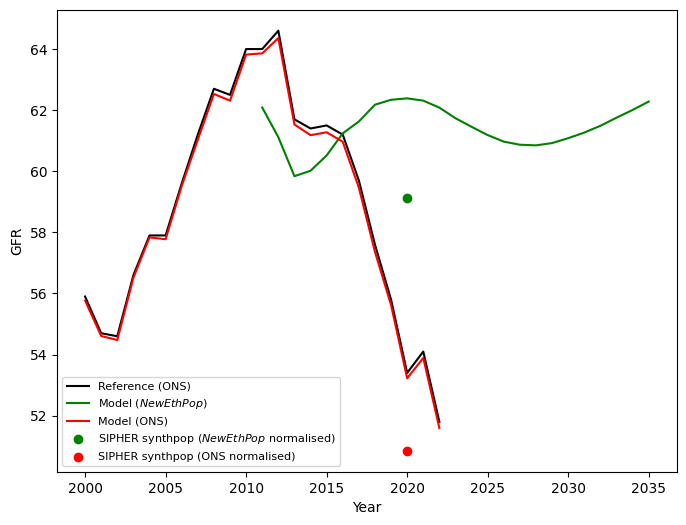

In [31]:
# Plot up GFR (births/female population, 15-44) against reference data
model_data_nep = pd.Series({2011: 62.0863,
                            2012: 61.1154,
                            2013: 59.8382,
                            2014: 60.0165,
                            2015: 60.5185,
                            2016: 61.241,
                            2017: 61.629,
                            2018: 62.1785,
                            2019: 62.3398,
                            2020: 62.3867,
                            2021: 62.3117,
                            2022: 62.0833,
                            2023: 61.7361,
                            2024: 61.4552,
                            2025: 61.1848,
                            2026: 60.9705,
                            2027: 60.8688,
                            2028: 60.8483,
                            2029: 60.9237,
                            2030: 61.083,
                            2031: 61.2666,
                            2032: 61.4888,
                            2033: 61.7539,
                            2034: 62.0072,
                            2035: 62.2819,
                           })

model_data_ons = pd.Series({2000: 55.7705,
                            2001: 54.6093,
                            2002: 54.4762,
                            2003: 56.5162,
                            2004: 57.8353,
                            2005: 57.776,
                            2006: 59.5188,
                            2007: 61.0349,
                            2008: 62.5305,
                            2009: 62.3103,
                            2010: 63.8195,
                            2011: 63.8589,
                            2012: 64.36,
                            2013: 61.5309,
                            2014: 61.1811,
                            2015: 61.2765,
                            2016: 60.9644,
                            2017: 59.4641,
                            2018: 57.364,
                            2019: 55.6195,
                            2020: 53.2242,
                            2021: 53.891,
                            2022: 51.595,
                           })

synthpop_result_nep = {2020: 59.1167,
                      }
synthpop_result_ons = {2020: 50.8544,
                      }

ref_data = futils.get_fertility_reference_data()
ref_data = ref_data.loc[ref_data.index >= 2000]['gfr_ref']

# ref_data_hfd = futils.get_fertility_reference_data(sources={'gfr': 'hfd', 'mort': 'ons', 'tfr': 'ons', 'cbr': 'ons', 'sma': 'ons'})
# ref_data_hfd = ref_data_hfd['gfr_ref']

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)

ax1.plot(ref_data, label='Reference (ONS)', c='black')
# ax1.plot(ref_data, label='Reference (HFD)', c='gray')
ax1.plot(model_data_nep, label='Model ($\it{NewEthPop}$)', c='green')
ax1.plot(model_data_ons, label='Model (ONS)', c='red')
ax1.scatter(*zip(*synthpop_result_nep.items()), label='SIPHER synthpop ($\it{NewEthPop}$ normalised)', c='green')
ax1.scatter(*zip(*synthpop_result_ons.items()), label='SIPHER synthpop (ONS normalised)', c='red')

plt.xlabel('Year')
plt.ylabel('GFR')
plt.legend(loc=3, prop={'size': 8})
plt.show()